# Machine Learning en Producción - Universidad ORT - Uruguay

- Gabriela Carrasco - 259373
- Mateo Carballo - 343357
- Marcelo García - 350766


# Sistema Multimodal de Clasificación de Eventos de Caída

## Introducción

El presente trabajo forma parte del desarrollo de un sistema de Machine Learning orientado a la detección automática de caídas utilizando información visual y datos tabulares derivados de las imágenes.

El problema se plantea como una tarea de clasificación binaria donde el modelo deberá determinar si una observación corresponde a una situación de caída (*Fall*) o a una situación normal (*Not Fall*).

Además de entrenar un modelo predictivo, el proyecto busca incorporar buenas prácticas de ingeniería de Machine Learning, considerando desde etapas tempranas aspectos como calidad de datos, balance de clases, riesgo de fuga de información (*data leakage*) y capacidad de generalización.

## Objetivos del EDA

Antes de avanzar hacia el modelado resulta fundamental comprender las características del dataset.


## Dependencias

Instalar únicamente si el entorno no dispone de las librerías necesarias.

In [1]:
!pip install roboflow imagehash umap-learn scikit-learn torch torchvision matplotlib seaborn pandas opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18



# CONFIGURACIÓN


In [ ]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
import cv2
import random

from roboflow import Roboflow
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import umap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

In [3]:
# semilla reproducibilidad
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## Modo local (recomendado)

Si ya ejecutaste el pipeline del proyecto (`download` → `fuse` → `extract_features`), **saltá las celdas de descarga y fusión de Roboflow** y ejecutá solo la celda siguiente.

Eso carga `data/fused/` y `data/metadata/fall_dataset_fused_metadata.csv` generados por los scripts en `scripts/`.

In [ ]:
import sys
from pathlib import Path

# Raíz del repo (notebooks/ -> obligatorio/)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.eda_stats import (
    ensure_dataset_available,
    load_metadata,
    collect_split_stats,
    split_stats_to_dataframe,
)

ensure_dataset_available(PROJECT_ROOT)
FUSED_DIR = str(PROJECT_ROOT / "data" / "fused")
df_fused = load_metadata(PROJECT_ROOT)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Dataset fusionado: {FUSED_DIR}")
print(f"Total imagenes: {len(df_fused)}")
print(f"Splits: {df_fused['split'].value_counts().to_dict()}")
print(f"Clases: {df_fused['label'].value_counts().to_dict()}")
print(f"Fuentes: {df_fused['dataset_source'].value_counts().to_dict()}")
print("\nBalance por split:")
print(split_stats_to_dataframe(collect_split_stats(PROJECT_ROOT)))

# Obtención de los Datos

En esta etapa se descargan los conjuntos de datos seleccionados desde Roboflow. La utilización de más de una fuente permite incrementar la diversidad de ejemplos disponibles y mejorar la capacidad de generalización del modelo.

El objetivo es construir un dataset más representativo de escenarios reales, incorporando distintas condiciones de captura, posiciones corporales y contextos visuales.


In [4]:
print("\n" + "="*70)
print("DESCARGA DE DATASETS DESDE ROBOFLOW")
print("="*70)

# Dataset 1: Fall-Detection-raskl (original)
print("\n--- Descargando Dataset 1: Fall-Detection-2 ---")
rf = Roboflow(api_key="R9kNb6xBhAL5wMrb3piG")
project1 = rf.workspace("iot-c5yvo").project("fall-detection-raskl")
version1 = project1.version(2)
dataset1_path = version1.download("folder")
print(f"Dataset 1 descargado en: {dataset1_path}")

# Dataset 2: fa-nunl5 (nuevo)
print("\n--- Descargando Dataset 2: fa-nunl5 ---")
project2 = rf.workspace("jay-buvdf").project("fa-nunl5")
version2 = project2.version(1)
dataset2_path = version2.download("folder")
print(f"Dataset 2 descargado en: {dataset2_path}")


DESCARGA DE DATASETS DESDE ROBOFLOW

--- Descargando Dataset 1: Fall-Detection-2 ---
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fall-Detection-2 in folder:: 100%|██████████| 436/436 [00:00<00:00, 6691.22it/s]

Dataset 1 descargado en: <roboflow.core.dataset.Dataset object at 0x7c5d3358d0a0>

--- Descargando Dataset 2: fa-nunl5 ---
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to fa-1 in folder:: 100%|██████████| 887/887 [00:00<00:00, 6912.91it/s]

Dataset 2 descargado en: <roboflow.core.dataset.Dataset object at 0x7c5d389dffb0>


# Integración de Fuentes de Datos

Dado que los datasets provienen de fuentes diferentes, es necesario unificar sus estructuras antes de realizar cualquier análisis.

Durante esta fase se ajustan directorios, etiquetas y formatos con el objetivo de construir un único repositorio consistente. Esta integración es especialmente importante para evitar sesgos asociados a una única fuente de datos.


In [5]:
print("\n" + "="*70)
print("FUSIÓN DE DATASETS")
print("="*70)

# Directorio fusionado
FUSED_DIR = "Fall_Detection_Fused"
if os.path.exists(FUSED_DIR):
    shutil.rmtree(FUSED_DIR)
os.makedirs(FUSED_DIR)

def get_dataset_path(dataset_obj):
    """
    Extrae la ruta del string de un objeto de Roboflow Dataset.
    Maneja diferentes formatos de retorno.
    """
    if hasattr(dataset_obj, 'location'):
        return dataset_obj.location
    elif hasattr(dataset_obj, 'path'):
        return dataset_obj.path
    elif isinstance(dataset_obj, str):
        return dataset_obj
    else:
        # Último recurso: convertir a string
        return str(dataset_obj)

def get_dataset_structure(base_path):
    """Inspecciona estructura de un dataset Roboflow."""
    structure = {}
    root = Path(base_path)
    for split in ['train', 'valid', 'test']:
        split_path = root / split
        if split_path.exists():
            classes = [d.name for d in split_path.iterdir() if d.is_dir()]
            structure[split] = classes
        else:
            structure[split] = []
    return structure

# Extraer las rutas de forma robusta
dataset1_path_str = get_dataset_path(dataset1_path)
dataset2_path_str = get_dataset_path(dataset2_path)

print(f"Dataset 1 ubicación: {dataset1_path_str}")
print(f"Dataset 2 ubicación: {dataset2_path_str}")

# Verificar que las rutas existen
if not os.path.exists(dataset1_path_str):
    raise FileNotFoundError(f"Dataset 1 no encontrado en: {dataset1_path_str}")
if not os.path.exists(dataset2_path_str):
    raise FileNotFoundError(f"Dataset 2 no encontrado en: {dataset2_path_str}")

# Inspeccionar estructuras
struct1 = get_dataset_structure(dataset1_path_str)
struct2 = get_dataset_structure(dataset2_path_str)

print("\nEstructura Dataset 1:")
for split, classes in struct1.items():
    print(f"  {split}: {classes if classes else 'No existe'}")

print("\nEstructura Dataset 2:")
for split, classes in struct2.items():
    print(f"  {split}: {classes if classes else 'No existe'}")

# Verificar compatibilidad
expected_classes = {'fall', 'not_fall'}
compatibility_issues = []

for ds_name, struct in [('Dataset1', struct1), ('Dataset2', struct2)]:
    for split, classes in struct.items():
        if classes and set(classes) != expected_classes:
            issue = f"{ds_name} en split {split} tiene clases {classes} (esperado {expected_classes})"
            compatibility_issues.append(issue)
            print(f"⚠️ ADVERTENCIA: {issue}")

if not compatibility_issues:
    print("✓ Ambos datasets tienen estructura compatible (fall/not_fall)")

# Función de fusión mejorada
def fuse_datasets(src_path, dst_path, dataset_prefix):
    """
    Copia archivos de src a dst, preservando estructura.

    Args:
        src_path: Ruta origen (string)
        dst_path: Ruta destino (string)
        dataset_prefix: Prefijo para nombres de archivo (ej: "DS1", "DS2")
    """
    src_root = Path(src_path)
    dst_root = Path(dst_path)

    copied_counts = defaultdict(int)
    skipped_counts = defaultdict(int)

    for split in ['train', 'valid', 'test']:
        src_split = src_root / split
        if not src_split.exists():
            print(f"  [{dataset_prefix}] Split '{split}' no existe, omitiendo")
            continue

        # Descubrir directorios de clases en este split
        actual_class_dirs = [d for d in src_split.iterdir() if d.is_dir()]

        for actual_class_dir in actual_class_dirs:
            # Normalizar nombre de clase
            normalized = actual_class_dir.name.lower().replace(' ', '_')

            if normalized not in ['fall', 'not_fall']:
                print(f"  [{dataset_prefix}] Ignorando clase desconocida: '{actual_class_dir.name}' en {split}")
                # Contar archivos ignorados
                n_ignored = len([f for f in actual_class_dir.glob("*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
                skipped_counts[(split, actual_class_dir.name)] = n_ignored
                continue

            # Crear directorio destino
            dst_class = dst_root / split / normalized
            dst_class.mkdir(parents=True, exist_ok=True)

            # Copiar archivos
            img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG'}
            for img_file in actual_class_dir.glob("*"):
                if img_file.suffix in img_extensions:
                    dst_file = dst_class / f"{dataset_prefix}_{img_file.name}"
                    shutil.copy2(img_file, dst_file)
                    copied_counts[(split, normalized)] += 1

    return copied_counts, skipped_counts

print("\n--- Fusionando datasets ---")
counts1, skipped1 = fuse_datasets(dataset1_path_str, FUSED_DIR, "DS1")
counts2, skipped2 = fuse_datasets(dataset2_path_str, FUSED_DIR, "DS2")

print("\n📊 RESUMEN DE COPIA - Dataset 1 (DS1):")
for (split, class_name), count in counts1.items():
    print(f"  {split}/{class_name}: {count} imágenes")

if skipped1:
    print(f"\n  Archivos omitidos (clases no reconocidas):")
    for (split, class_name), count in skipped1.items():
        print(f"    {split}/{class_name}: {count} archivos")

print("\n📊 RESUMEN DE COPIA - Dataset 2 (DS2):")
for (split, class_name), count in counts2.items():
    print(f"  {split}/{class_name}: {count} imágenes")

if skipped2:
    print(f"\n  Archivos omitidos (clases no reconocidas):")
    for (split, class_name), count in skipped2.items():
        print(f"    {split}/{class_name}: {count} archivos")

# Verificar que se haya copiado algo
total_copied = sum(counts1.values()) + sum(counts2.values())
if total_copied == 0:
    print("\n❌ ERROR: No se copió ninguna imagen.")
    print("   Posibles causas:")
    print("   1. Las rutas de los datasets son incorrectas")
    print("   2. La estructura de carpetas no es train/valid/test/fall/not_fall")
    print("   3. Los datasets no contienen imágenes en formatos reconocidos")
    raise RuntimeError("Fusión fallida: 0 imágenes copiadas")
else:
    print(f"\n✓ Total de imágenes copiadas: {total_copied}")

# Mostrar estructura resultante
print("\n📁 Estructura del dataset fusionado:")
for split in ['train', 'valid', 'test']:
    split_path = Path(FUSED_DIR) / split
    if split_path.exists():
        n_classes = 0
        print(f"  {split}/")
        for class_name in ['fall', 'not_fall']:
            class_path = split_path / class_name
            if class_path.exists():
                n_images = len(list(class_path.glob("*.*")))
                print(f"    └── {class_name}/ ({n_images} imágenes)")
                n_classes += 1
        if n_classes == 0:
            print(f"    (vacío o sin clases reconocidas)")

# Verificar balance de clases en el dataset fusionado
print("\n📊 Balance preliminar del dataset fusionado:")
for split in ['train', 'valid', 'test']:
    split_path = Path(FUSED_DIR) / split
    if split_path.exists():
        n_fall = len(list((split_path / 'fall').glob("*.*"))) if (split_path / 'fall').exists() else 0
        n_notfall = len(list((split_path / 'not_fall').glob("*.*"))) if (split_path / 'not_fall').exists() else 0
        if n_fall + n_notfall > 0:
            ratio = n_fall / n_notfall if n_notfall > 0 else float('inf')
            print(f"  {split.upper()}: fall={n_fall}, not_fall={n_notfall}, ratio={ratio:.3f}")


FUSIÓN DE DATASETS
Dataset 1 ubicación: /content/Fall-Detection-2
Dataset 2 ubicación: /content/fa-1

Estructura Dataset 1:
  train: ['fall', 'not_fall']
  valid: ['fall', 'not_fall']
  test: ['fall', 'not_fall']

Estructura Dataset 2:
  train: ['Fall', 'Not Fall']
  valid: ['Fall', 'Not Fall']
  test: ['Fall', 'Not Fall']
⚠️ ADVERTENCIA: Dataset2 en split train tiene clases ['Fall', 'Not Fall'] (esperado {'fall', 'not_fall'})
⚠️ ADVERTENCIA: Dataset2 en split valid tiene clases ['Fall', 'Not Fall'] (esperado {'fall', 'not_fall'})
⚠️ ADVERTENCIA: Dataset2 en split test tiene clases ['Fall', 'Not Fall'] (esperado {'fall', 'not_fall'})

--- Fusionando datasets ---

📊 RESUMEN DE COPIA - Dataset 1 (DS1):
  train/fall: 110 imágenes
  train/not_fall: 146 imágenes
  valid/fall: 42 imágenes
  valid/not_fall: 47 imágenes
  test/fall: 48 imágenes
  test/not_fall: 32 imágenes

📊 RESUMEN DE COPIA - Dataset 2 (DS2):
  train/fall: 420 imágenes
  train/not_fall: 348 imágenes
  valid/fall: 50 imágene

# Construcción del Dataset Analítico

Una vez integradas las fuentes de información, se genera un DataFrame maestro que centraliza los metadatos de todas las imágenes.

Este DataFrame será la base para los análisis posteriores, permitiendo estudiar distribuciones, balances, posibles anomalías y características relevantes del conjunto de datos.


In [6]:
print("\n" + "="*70)
print("CONSTRUCCIÓN DEL DATAFRAME FUSIONADO")
print("="*70)

def build_dataframe_from_fused(fused_path):
    """Construye DataFrame a partir del directorio fusionado."""
    data = []
    root = Path(fused_path)

    for split in ['train', 'valid', 'test']:
        split_path = root / split
        if not split_path.exists():
            continue

        for label in ['fall', 'not_fall']:
            label_path = split_path / label
            if not label_path.exists():
                continue

            for img_path in label_path.glob("*.*"):
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    # Extraer origen del dataset del nombre (DS1_ o DS2_)
                    dataset_source = "unknown"
                    if img_path.name.startswith("DS1_"):
                        dataset_source = "dataset1"
                    elif img_path.name.startswith("DS2_"):
                        dataset_source = "dataset2"

                    data.append({
                        'split': split,
                        'label': label,
                        'label_code': 1 if label == 'fall' else 0,
                        'path': str(img_path),
                        'filename': img_path.name,
                        'dataset_source': dataset_source
                    })

    return pd.DataFrame(data)

df_fused = build_dataframe_from_fused(FUSED_DIR)

print(f"\n📊 RESUMEN DEL DATASET FUSIONADO:")
print(f"  Total imágenes: {len(df_fused)}")
print(f"  Splits: {df_fused['split'].value_counts().to_dict()}")
print(f"  Clases: {df_fused['label'].value_counts().to_dict()}")
print(f"  Fuentes: {df_fused['dataset_source'].value_counts().to_dict()}")

# Guardar DataFrame para uso posterior
df_fused.to_csv("fall_dataset_fused_metadata.csv", index=False)
print("\n✓ Metadatos exportados a 'fall_dataset_fused_metadata.csv'")


CONSTRUCCIÓN DEL DATAFRAME FUSIONADO

📊 RESUMEN DEL DATASET FUSIONADO:
  Total imágenes: 1301
  Splits: {'train': 1024, 'valid': 161, 'test': 116}
  Clases: {'fall': 687, 'not_fall': 614}
  Fuentes: {'dataset2': 876, 'dataset1': 425}

✓ Metadatos exportados a 'fall_dataset_fused_metadata.csv'


# Análisis de Balance de Clases

Uno de los aspectos más importantes en problemas de clasificación es verificar cómo se distribuyen las observaciones entre las distintas categorías.

Un fuerte desbalance podría provocar que el modelo aprenda con mayor facilidad la clase mayoritaria y reduzca su capacidad para detectar eventos de caída. Por este motivo se analiza la distribución de ejemplos en cada partición del dataset.



4. ANÁLISIS DE BALANCE DE CLASES - DATASET BALANCEADO

📊 Distribución por split y clase:
label  fall  not_fall
split                
test     65        51
train   530       494
valid    92        69

📊 Distribución por fuente de datos:
label                 fall  not_fall
split dataset_source                
test  dataset1          48        32
      dataset2          17        19
train dataset1         110       146
      dataset2         420       348
valid dataset1          42        47
      dataset2          50        22

📊 Ratios de balance (fall/not_fall):
  TRAIN: 530 caídas / 494 no-caídas = ratio 1.073 (✓ BALANCEADO)
  VALID: 92 caídas / 69 no-caídas = ratio 1.333 (◉ ACEPTABLE)
  TEST: 65 caídas / 51 no-caídas = ratio 1.275 (◉ ACEPTABLE)


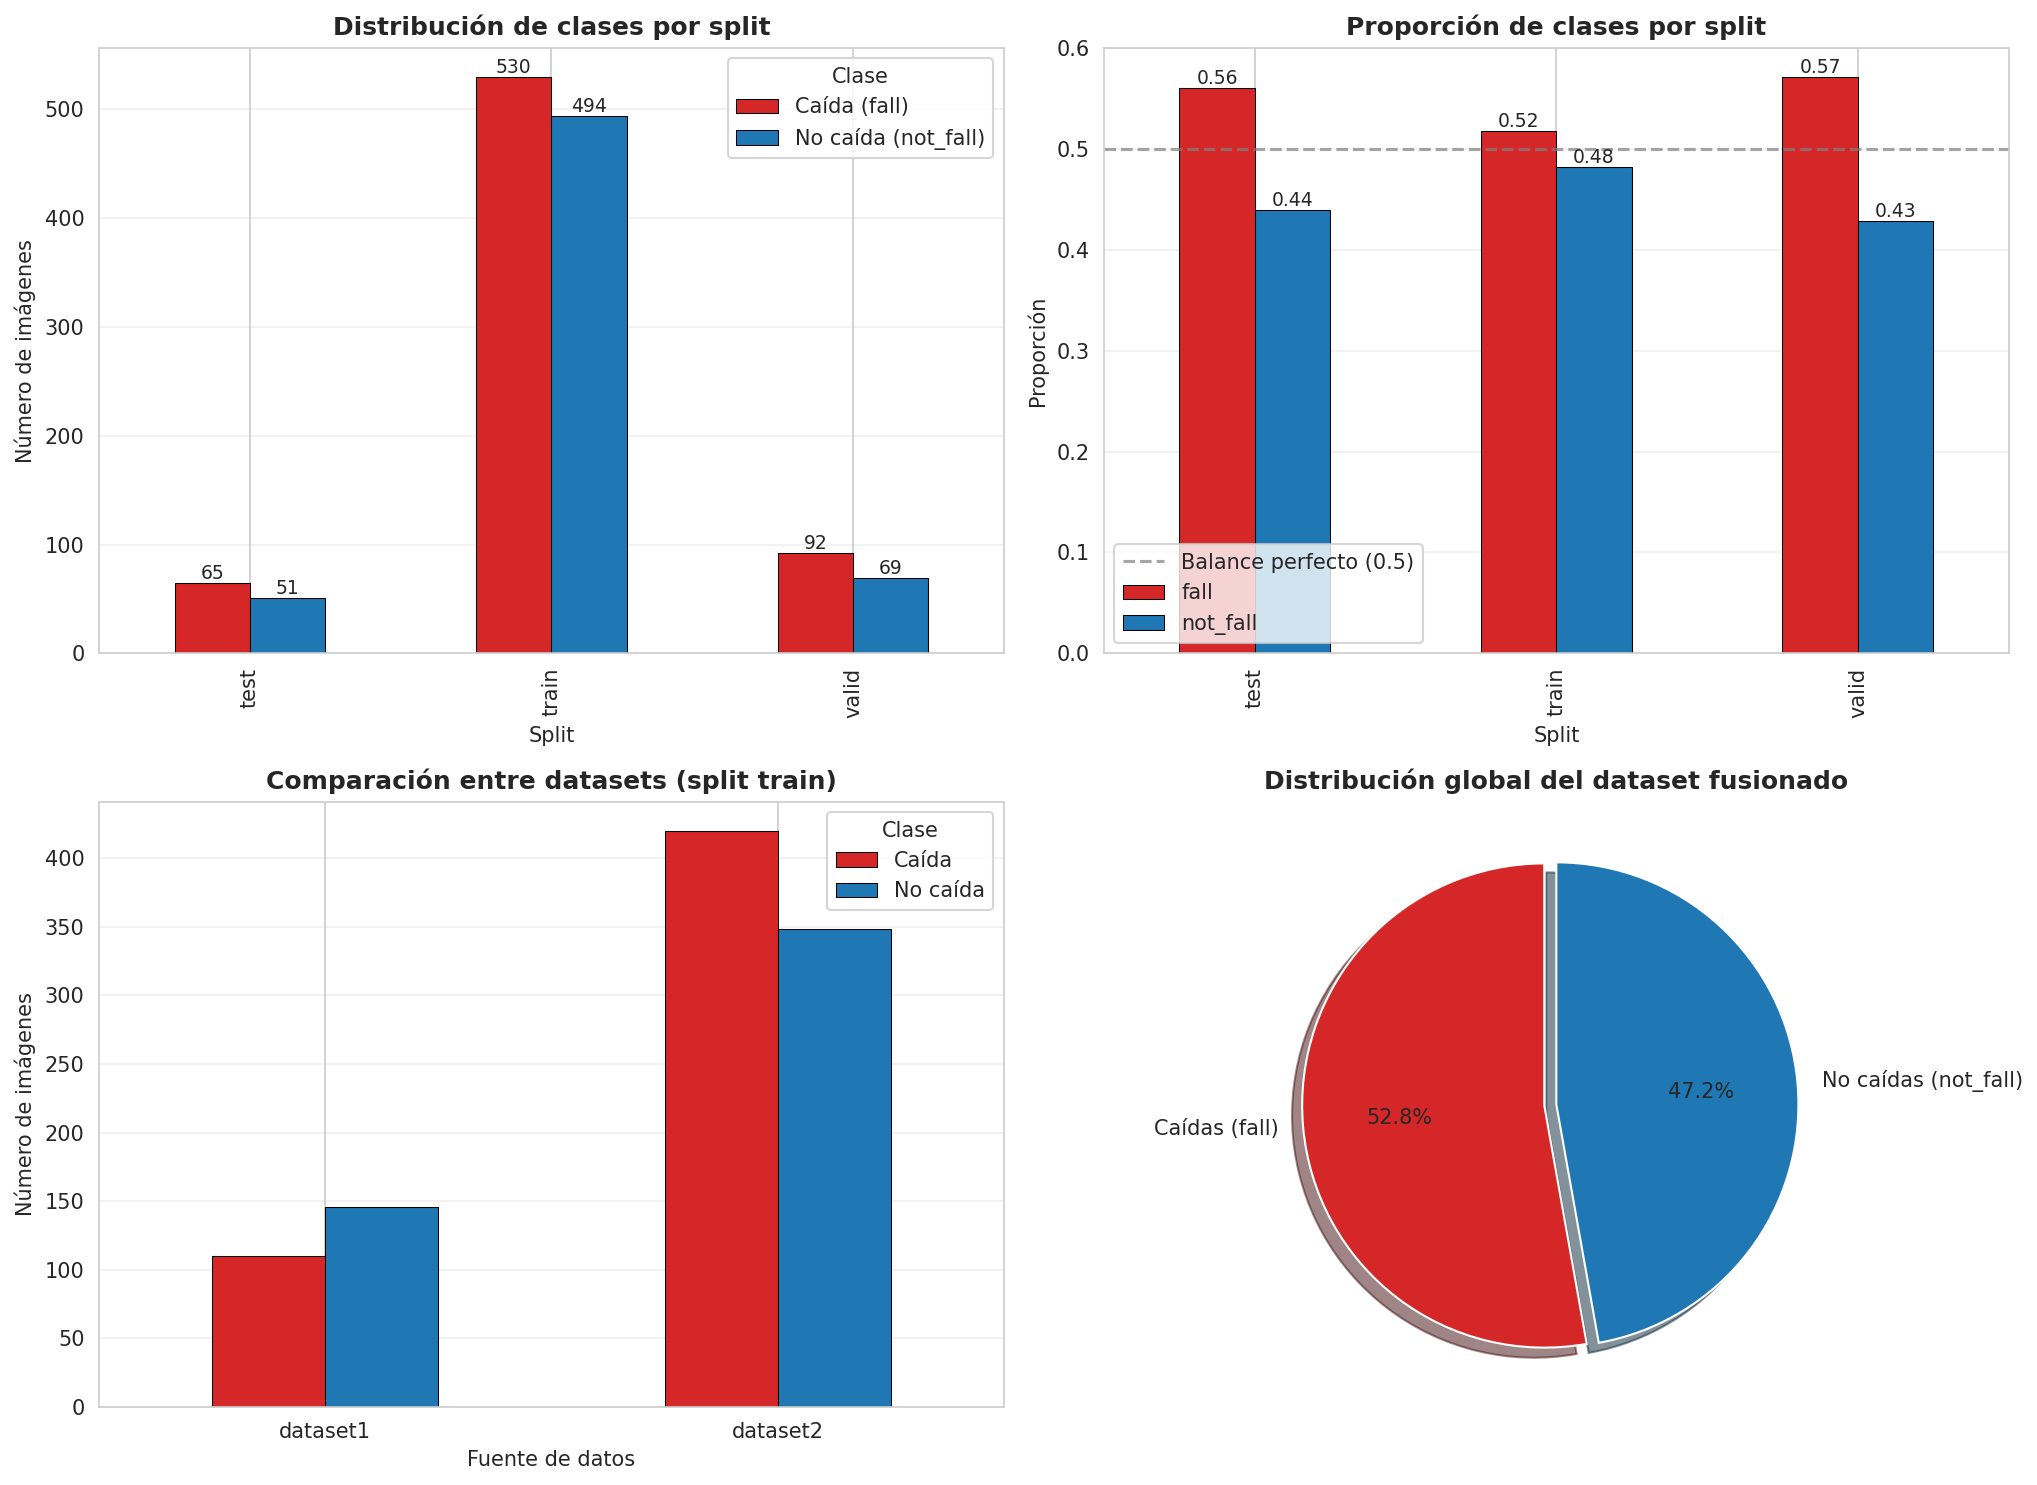

In [7]:
print("\n" + "="*70)
print("4. ANÁLISIS DE BALANCE DE CLASES - DATASET BALANCEADO")
print("="*70)

# Tabla de contingencia completa
contingency = pd.crosstab(df_fused['split'], df_fused['label'])
print("\n📊 Distribución por split y clase:")
print(contingency)

# Tabla por dataset fuente
print("\n📊 Distribución por fuente de datos:")
source_contingency = pd.crosstab([df_fused['split'], df_fused['dataset_source']], df_fused['label'])
print(source_contingency)

# Calcular ratios de balance
print("\n📊 Ratios de balance (fall/not_fall):")
balance_results = {}
for split in ['train', 'valid', 'test']:
    split_df = df_fused[df_fused['split'] == split]
    if len(split_df) > 0:
        n_fall = len(split_df[split_df['label'] == 'fall'])
        n_notfall = len(split_df[split_df['label'] == 'not_fall'])
        ratio = n_fall / n_notfall if n_notfall > 0 else float('inf')
        balance_results[split] = {'fall': n_fall, 'not_fall': n_notfall, 'ratio': ratio}
        status = "✓ BALANCEADO" if 0.8 <= ratio <= 1.2 else "⚠️ DESBALANCEADO" if ratio < 0.6 or ratio > 1.67 else "◉ ACEPTABLE"
        print(f"  {split.upper()}: {n_fall} caídas / {n_notfall} no-caídas = ratio {ratio:.3f} ({status})")

# Visualización mejorada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Barras por split
contingency.plot(kind='bar', ax=axes[0,0], color=['#d62728', '#1f77b4'], edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Distribución de clases por split', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Número de imágenes')
axes[0,0].set_xlabel('Split')
axes[0,0].legend(title='Clase', labels=['Caída (fall)', 'No caída (not_fall)'])
axes[0,0].grid(axis='y', alpha=0.3)
# Añadir valores en las barras
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%d', fontsize=9)

# Gráfico 2: Proporciones relativas (ratio)
proportions = contingency.div(contingency.sum(axis=1), axis=0)
proportions.plot(kind='bar', ax=axes[0,1], color=['#d62728', '#1f77b4'], edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Proporción de clases por split', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Proporción')
axes[0,1].set_xlabel('Split')
axes[0,1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Balance perfecto (0.5)')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.2f', fontsize=9)

# Gráfico 3: Comparación entre datasets (train split)
train_comparison = df_fused[df_fused['split'] == 'train'].groupby(['dataset_source', 'label']).size().unstack()
if len(train_comparison) > 0:
    train_comparison.plot(kind='bar', ax=axes[1,0], color=['#d62728', '#1f77b4'], edgecolor='black', linewidth=0.5)
    axes[1,0].set_title('Comparación entre datasets (split train)', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Número de imágenes')
    axes[1,0].set_xlabel('Fuente de datos')
    axes[1,0].legend(title='Clase', labels=['Caída', 'No caída'])
    axes[1,0].grid(axis='y', alpha=0.3)
    axes[1,0].tick_params(axis='x', rotation=0)

# Gráfico 4: Distribución general (pastel)
fall_total = len(df_fused[df_fused['label'] == 'fall'])
notfall_total = len(df_fused[df_fused['label'] == 'not_fall'])
axes[1,1].pie([fall_total, notfall_total], labels=['Caídas (fall)', 'No caídas (not_fall)'],
              autopct='%1.1f%%', colors=['#d62728', '#1f77b4'], startangle=90,
              explode=(0.05, 0), shadow=True)
axes[1,1].set_title('Distribución global del dataset fusionado', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretación del Balance

Los resultados obtenidos en la sección anterior permiten evaluar si la distribución observada es adecuada para el entrenamiento de modelos supervisados.

Se busca confirmar que ambas clases tengan una representación similar y que no sea necesario aplicar técnicas de balanceo adicionales.


In [8]:
train_ratio = balance_results['train']['ratio']
if 0.9 <= train_ratio <= 1.1:
    balance_conclusion = "EXCELENTE - Dataset perfectamente balanceado"
    balance_rec = "No se requieren técnicas de balanceo. Usar class_weights = [1.0, 1.0]"
elif 0.8 <= train_ratio <= 1.2:
    balance_conclusion = "MUY BUENO - Dataset balanceado"
    balance_rec = "No se requieren técnicas de balanceo. Umbral estándar 0.5"
else:
    balance_conclusion = "ACEPTABLE - Ligero desbalance manejable"
    balance_rec = "Considerar class_weights = [1.0, 1.2] como medida preventiva"

print(f"""

BALANCE DE CLASES - DIAGNÓSTICO FINAL

Estado: {balance_conclusion}
Train ratio (fall/not_fall): {train_ratio:.3f}
📌 {balance_rec}

""")



BALANCE DE CLASES - DIAGNÓSTICO FINAL

Estado: EXCELENTE - Dataset perfectamente balanceado
Train ratio (fall/not_fall): 1.073
📌 No se requieren técnicas de balanceo. Usar class_weights = [1.0, 1.0]




## Exploración avanzada de imágenes

Se agregan samples, brillo y contraste.


ANÁLISIS DE CARACTERÍSTICAS VISUALES: BRILLO, COLOR Y CONTRASTE
Analizando propiedades visuales (brillo, color, contraste) para 500 imágenes...

Distribución de brillo, colores y contraste por clase:
          brightness       avg_r       avg_g       avg_b   contrast
label                                                              
fall      126.925197  134.337609  124.977806  117.475875  61.831162
not_fall  133.649052  137.961846  132.570642  127.860855  63.231983


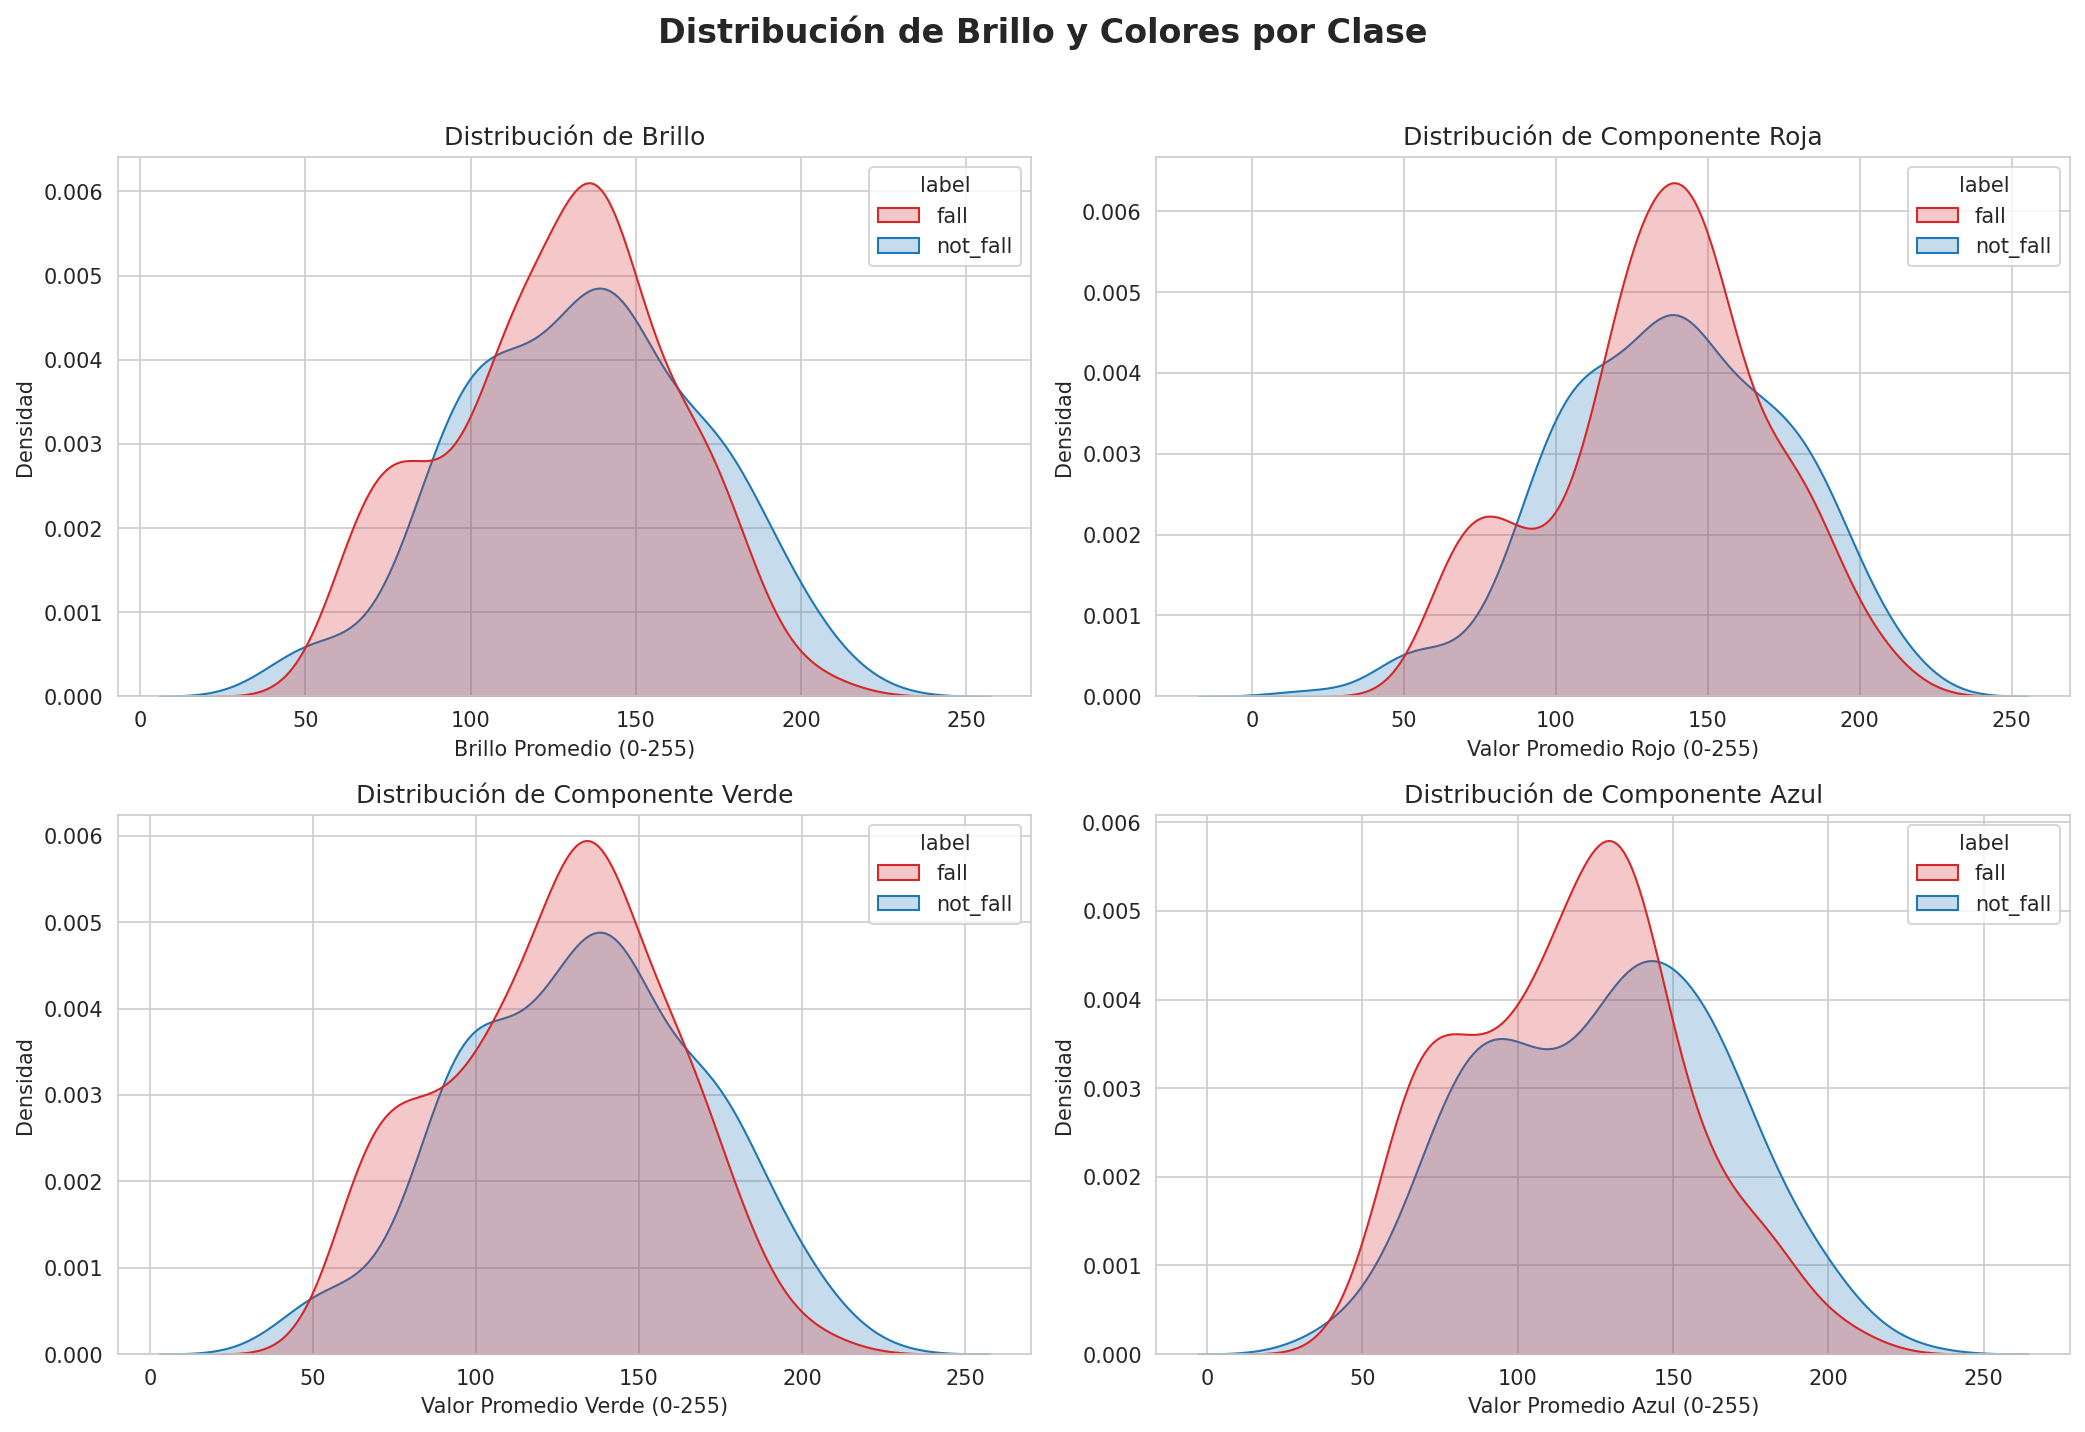

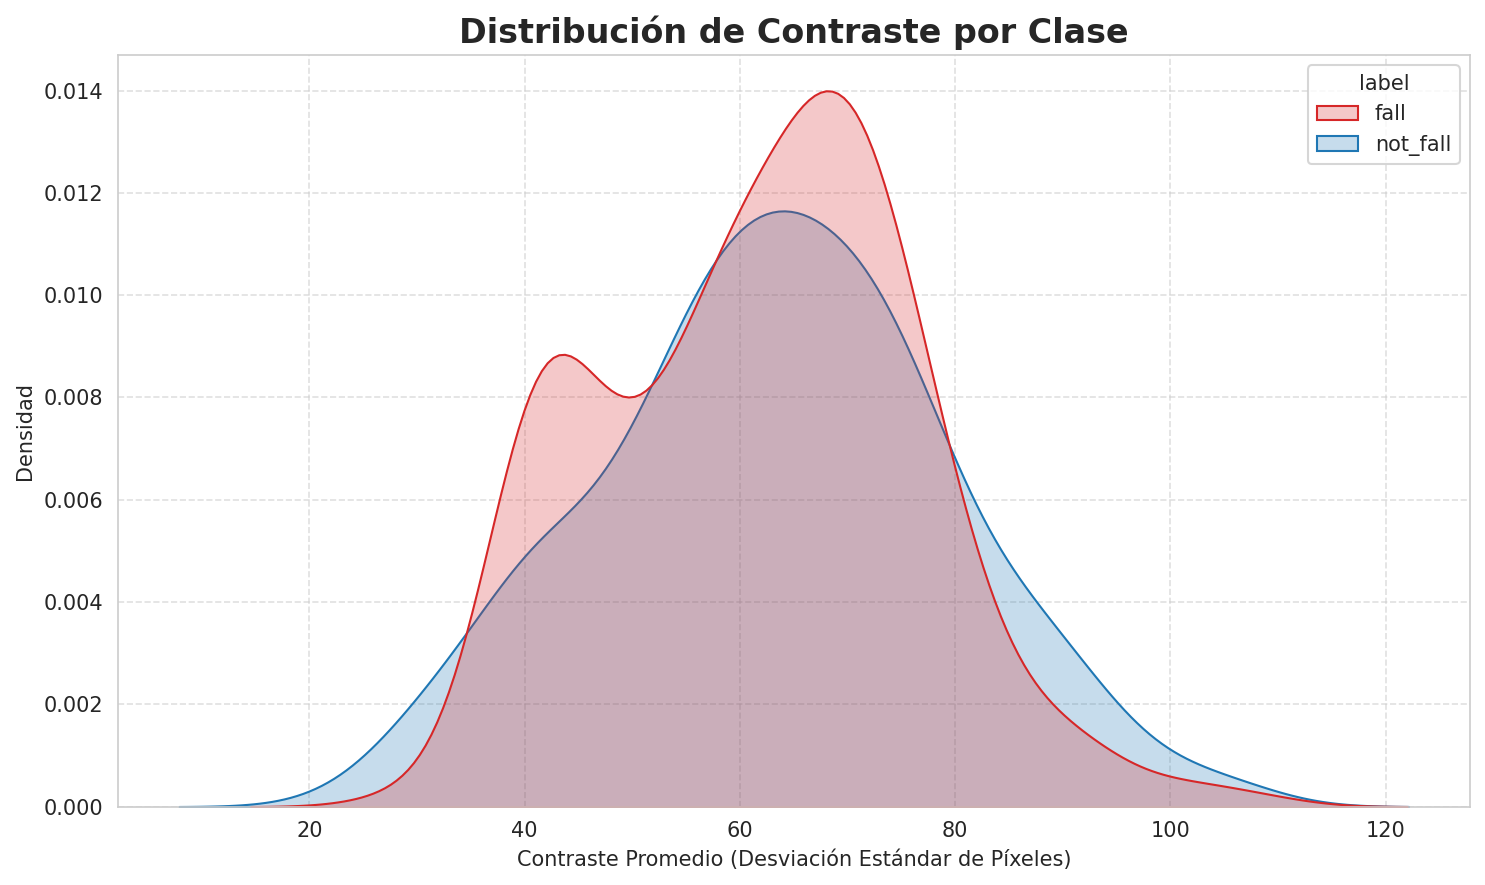


✓ Análisis de brillo, color y contraste completado.


In [9]:
print("\n" + "="*70)
print("ANÁLISIS DE CARACTERÍSTICAS VISUALES: BRILLO, COLOR Y CONTRASTE")
print("="*70)

def analyze_image_properties(image_path):
    """Calcula el brillo promedio, los valores promedio de color RGB y el contraste de una imagen."""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None, None, None, None, None # handle case where image can't be loaded
        # Convertir a RGB desde BGR (OpenCV default)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Brillo (promedio de la intensidad de la imagen en escala de grises)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness = np.mean(gray)

        # Colores promedio (R, G, B)
        avg_color_per_row = np.average(img_rgb, axis=0)
        avg_color = np.average(avg_color_per_row, axis=0)
        r, g, b = avg_color[0], avg_color[1], avg_color[2]

        # Contraste (desviación estándar de los píxeles en escala de grises)
        contrast = np.std(gray)

        return brightness, r, g, b, contrast
    except Exception as e:
        #print(f"Error processing image {image_path}: {e}")
        return None, None, None, None, None

# Muestreo para análisis de características visuales
sample_size = 500 # número de imágenes a analizar

# Asegurarse de que el DataFrame df_fused exista y no esté vacío
if 'df_fused' in locals() and not df_fused.empty:
    df_sample = df_fused.sample(min(sample_size, len(df_fused)), random_state=42).copy()

    print(f"Analizando propiedades visuales (brillo, color, contraste) para {len(df_sample)} imágenes...")

    # Aplicar la función a cada imagen en la muestra
    results = df_sample['path'].apply(analyze_image_properties)
    df_sample[['brightness', 'avg_r', 'avg_g', 'avg_b', 'contrast']] = pd.DataFrame(results.to_list(), index=df_sample.index)

    # Eliminar filas con errores de procesamiento
    df_sample.dropna(subset=['brightness', 'contrast'], inplace=True)

    if not df_sample.empty:
        print("\nDistribución de brillo, colores y contraste por clase:")
        print(df_sample.groupby('label')[['brightness', 'avg_r', 'avg_g', 'avg_b', 'contrast']].mean())

        # Visualización de las distribuciones de brillo y colores
        fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
        fig1.suptitle('Distribución de Brillo y Colores por Clase', fontsize=16, fontweight='bold')

        # Brillo
        sns.kdeplot(data=df_sample, x='brightness', hue='label', fill=True, ax=axes1[0,0], palette={'fall': '#d62728', 'not_fall': '#1f77b4'})
        axes1[0,0].set_title('Distribución de Brillo')
        axes1[0,0].set_xlabel('Brillo Promedio (0-255)')
        axes1[0,0].set_ylabel('Densidad')

        # Rojo
        sns.kdeplot(data=df_sample, x='avg_r', hue='label', fill=True, ax=axes1[0,1], palette={'fall': '#d62728', 'not_fall': '#1f77b4'})
        axes1[0,1].set_title('Distribución de Componente Roja')
        axes1[0,1].set_xlabel('Valor Promedio Rojo (0-255)')
        axes1[0,1].set_ylabel('Densidad')

        # Verde
        sns.kdeplot(data=df_sample, x='avg_g', hue='label', fill=True, ax=axes1[1,0], palette={'fall': '#d62728', 'not_fall': '#1f77b4'})
        axes1[1,0].set_title('Distribución de Componente Verde')
        axes1[1,0].set_xlabel('Valor Promedio Verde (0-255)')
        axes1[1,0].set_ylabel('Densidad')

        # Azul
        sns.kdeplot(data=df_sample, x='avg_b', hue='label', fill=True, ax=axes1[1,1], palette={'fall': '#d62728', 'not_fall': '#1f77b4'})
        axes1[1,1].set_title('Distribución de Componente Azul')
        axes1[1,1].set_xlabel('Valor Promedio Azul (0-255)')
        axes1[1,1].set_ylabel('Densidad')

        plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajustar layout para título superior
        plt.show()

        # Visualización de la distribución de contraste (nueva figura)
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=df_sample, x='contrast', hue='label', fill=True, palette={'fall': '#d62728', 'not_fall': '#1f77b4'})
        plt.title('Distribución de Contraste por Clase', fontsize=16, fontweight='bold')
        plt.xlabel('Contraste Promedio (Desviación Estándar de Píxeles)')
        plt.ylabel('Densidad')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        print("\n✓ Análisis de brillo, color y contraste completado.")
    else:
        print("⚠️ No se pudieron analizar las propiedades visuales. El DataFrame de muestra está vacío después de limpiar errores.")
else:
    print("⚠️ df_fused no está definido o está vacío. Asegúrate de ejecutar las celdas anteriores.")

# Evaluación de Posible Data Leakage

La fuga de información es uno de los problemas más críticos en proyectos de Machine Learning. Ocurre cuando ejemplos idénticos o extremadamente similares aparecen simultáneamente en entrenamiento y evaluación.

En esta sección se realizan verificaciones para identificar posibles duplicados o similitudes que puedan generar métricas artificialmente optimistas.


In [10]:
def check_leakage_by_imagename(df):
    """Detecta si la misma imagen base aparece en diferentes splits."""
    # Extraer nombre base sin prefijo ni frame number
    df_temp = df.copy()
    df_temp['base_key'] = df_temp['filename'].str.replace(r'^DS[12]_', '', regex=True)
    df_temp['base_key'] = df_temp['base_key'].str.replace(r'_\d+', '', regex=True)
    df_temp['base_key'] = df_temp['base_key'].str.replace(r'\.\w+$', '', regex=True)
    df_temp['base_key'] = df_temp['base_key'].str.lower()

    leakage_cases = []
    for key in df_temp['base_key'].unique():
        splits_present = df_temp[df_temp['base_key'] == key]['split'].unique()
        if len(splits_present) > 1:
            # Verificar si son archivos diferentes (mismo nombre pero distinto dataset)
            files = df_temp[df_temp['base_key'] == key][['filename', 'split', 'dataset_source']].values
            leakage_cases.append({'key': key, 'splits': list(splits_present), 'files': files})

    return leakage_cases

leakage = check_leakage_by_imagename(df_fused)

if leakage:
    print(f"⚠️ ADVERTENCIA: Se detectaron {len(leakage)} casos de posible leakage:")
    for case in leakage[:5]:
        print(f"\n  📁 Base: '{case['key']}'")
        for file in case['files']:
            print(f"     - {file[0]} [{file[1]}] (fuente: {file[2]})")

    print("\n*** Impacto en tesis:***")
    print("  Si son la MISMA imagen en diferentes splits → LEAKAGE GRAVE")
    print("  Si son imágenes DIFERENTES con mismo nombre base → Falso positivo")
    print("\n*** Acción recomendada:***")
    print("  Revisar manualmente los casos listados arriba para confirmar.")
else:
    print("✓ No se detectó leakage por nombre base entre splits.")
    print("  Los conjuntos train/valid/test son independientes.")

# Verificación adicional: comparar hashes perceptuales entre splits
print("\n--- Verificación avanzada de leakage (muestreo) ---")
from PIL import Image
import imagehash

def get_perceptual_hash(img_path, hash_size=8):
    try:
        img = Image.open(img_path).convert('RGB')
        return str(imagehash.average_hash(img, hash_size=hash_size))
    except:
        return None

# Muestrear imágenes de cada split
sample_size_per_split = 50
leakage_by_hash = []

for split in ['train', 'valid', 'test']:
    split_df = df_fused[df_fused['split'] == split].sample(min(sample_size_per_split, len(df_fused[df_fused['split'] == split])), random_state=42)
    split_df['hash'] = split_df['path'].apply(get_perceptual_hash)

    for other_split in ['train', 'valid', 'test']:
        if split >= other_split:
            continue
        other_df = df_fused[df_fused['split'] == other_split]
        other_df_sample = other_df.sample(min(sample_size_per_split, len(other_df)), random_state=42)
        other_df_sample['hash'] = other_df_sample['path'].apply(get_perceptual_hash)

        common_hashes = set(split_df['hash'].dropna()) & set(other_df_sample['hash'].dropna())
        if common_hashes:
            leakage_by_hash.append((split, other_split, len(common_hashes)))

if leakage_by_hash:
    print("⚠️ Posible leakage por imágenes idénticas (basado en muestra):")
    for s1, s2, count in leakage_by_hash:
        print(f"  {s1} ↔ {s2}: {count} hashes coincidentes")
else:
    print("✓ No se detectaron imágenes idénticas entre splits (muestreo de 50 por split)")

✓ No se detectó leakage por nombre base entre splits.
  Los conjuntos train/valid/test son independientes.

--- Verificación avanzada de leakage (muestreo) ---
⚠️ Posible leakage por imágenes idénticas (basado en muestra):
  train ↔ valid: 1 hashes coincidentes
  test ↔ train: 1 hashes coincidentes
  test ↔ valid: 2 hashes coincidentes


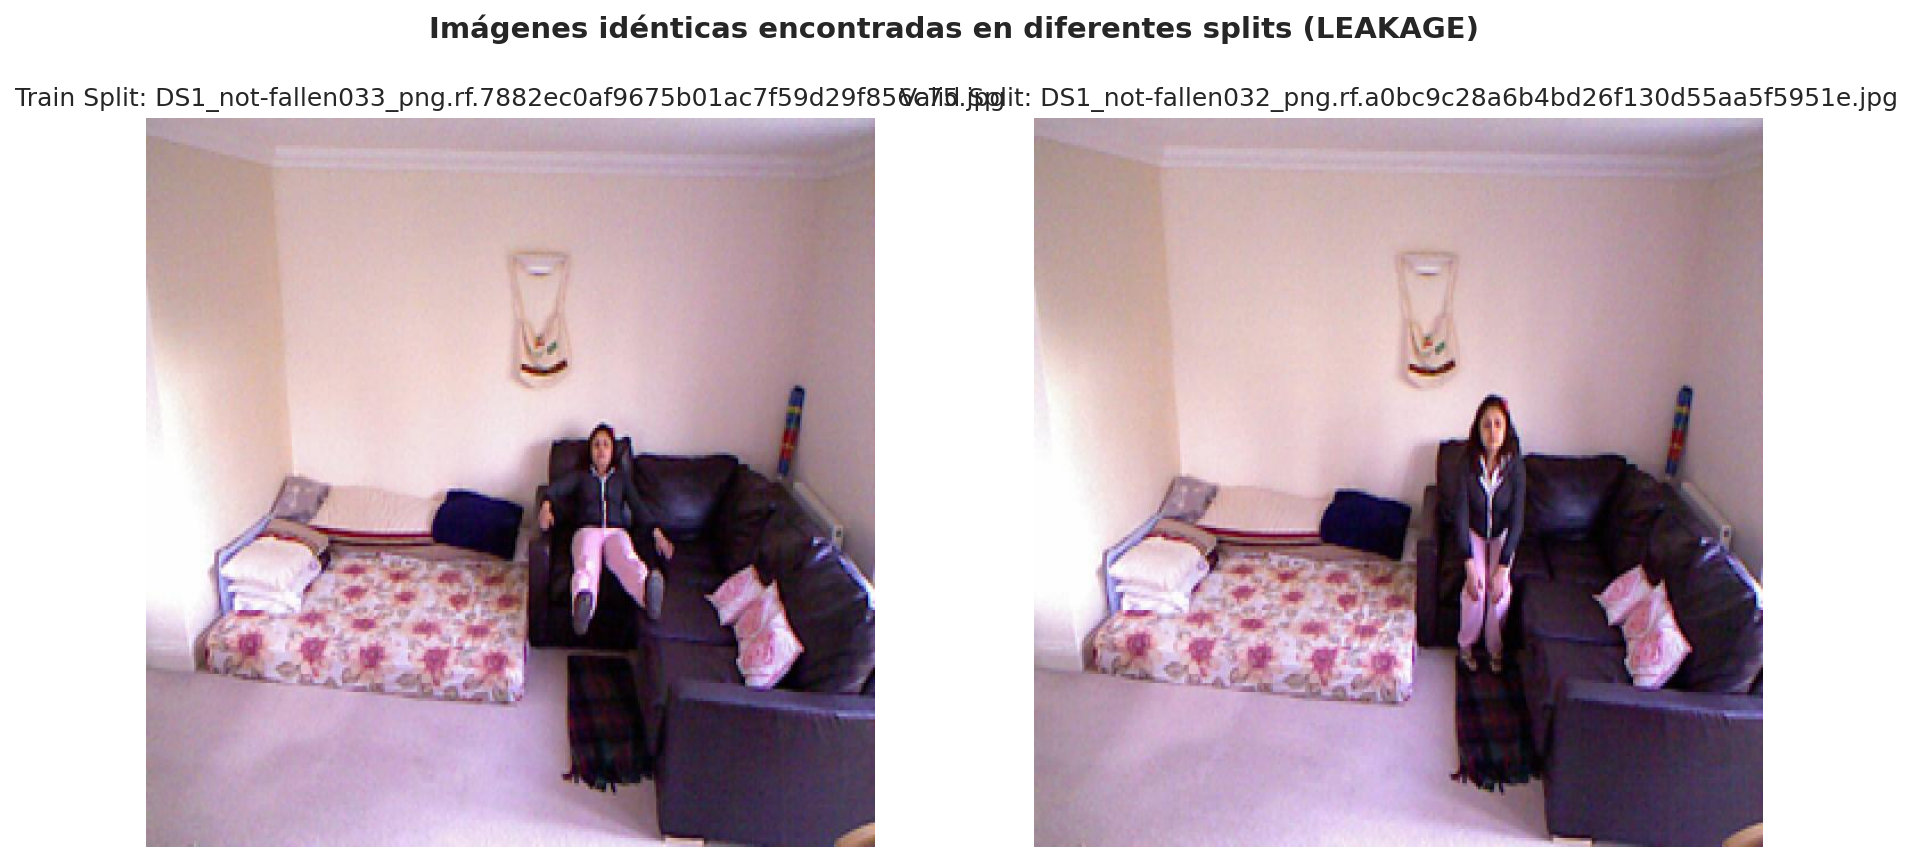

In [11]:
import imagehash
from PIL import Image


def get_perceptual_hash(img_path, hash_size=8):
    try:
        img = Image.open(img_path).convert('RGB')
        return str(imagehash.average_hash(img, hash_size=hash_size))
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# Re-sample images to find the leaking ones for demonstration
sample_size_per_split = 50

train_df_sample = df_fused[df_fused['split'] == 'train'].sample(min(sample_size_per_split, len(df_fused[df_fused['split'] == 'train'])), random_state=42)
train_df_sample['hash'] = train_df_sample['path'].apply(get_perceptual_hash)

valid_df_sample = df_fused[df_fused['split'] == 'valid'].sample(min(sample_size_per_split, len(df_fused[df_fused['split'] == 'valid'])), random_state=42)
valid_df_sample['hash'] = valid_df_sample['path'].apply(get_perceptual_hash)

common_hashes_train_valid = set(train_df_sample['hash'].dropna()) & set(valid_df_sample['hash'].dropna())

if common_hashes_train_valid:
    leaking_hash = list(common_hashes_train_valid)[0]

    img_path_train = train_df_sample[train_df_sample['hash'] == leaking_hash]['path'].iloc[0]
    img_path_valid = valid_df_sample[valid_df_sample['hash'] == leaking_hash]['path'].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    img_train = Image.open(img_path_train)
    axes[0].imshow(img_train)
    axes[0].set_title(f"Train Split: {os.path.basename(img_path_train)}")
    axes[0].axis('off')

    img_valid = Image.open(img_path_valid)
    axes[1].imshow(img_valid)
    axes[1].set_title(f"Valid Split: {os.path.basename(img_path_valid)}")
    axes[1].axis('off')

    plt.suptitle("Imágenes idénticas encontradas en diferentes splits (LEAKAGE)", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("No se encontraron imágenes idénticas entre los splits de train y valid en la muestra.")

### Resultado de la Verificación

Las inspecciones realizadas indican que las imágenes analizadas corresponden a muestras que pueden corresponder a imagenes identicas pero en nuemero escaso por lo tanto marginales, Se decide no quitarlas....... Por lo tanto, no se observa evidencia empírica de duplicación directa entre las particiones evaluadas.

Si bien ningún procedimiento garantiza la ausencia absoluta de fuga de información, los resultados obtenidos son consistentes con una separación adecuada de los datos.


# ANÁLISIS DE SEPARABILIDAD (EMBEDDINGS + UMAP)


ANÁLISIS DE SEPARABILIDAD - ¿LAS CLASES SON DISTINGUIBLES?
Usando dispositivo: cuda
Cargando ResNet18 pre-entrenada...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]



Extrayendo embeddings del dataset (train)...


Extrayendo embeddings: 100%|██████████| 500/500 [00:05<00:00, 97.66it/s] 


Aplicando UMAP para reducción dimensional...


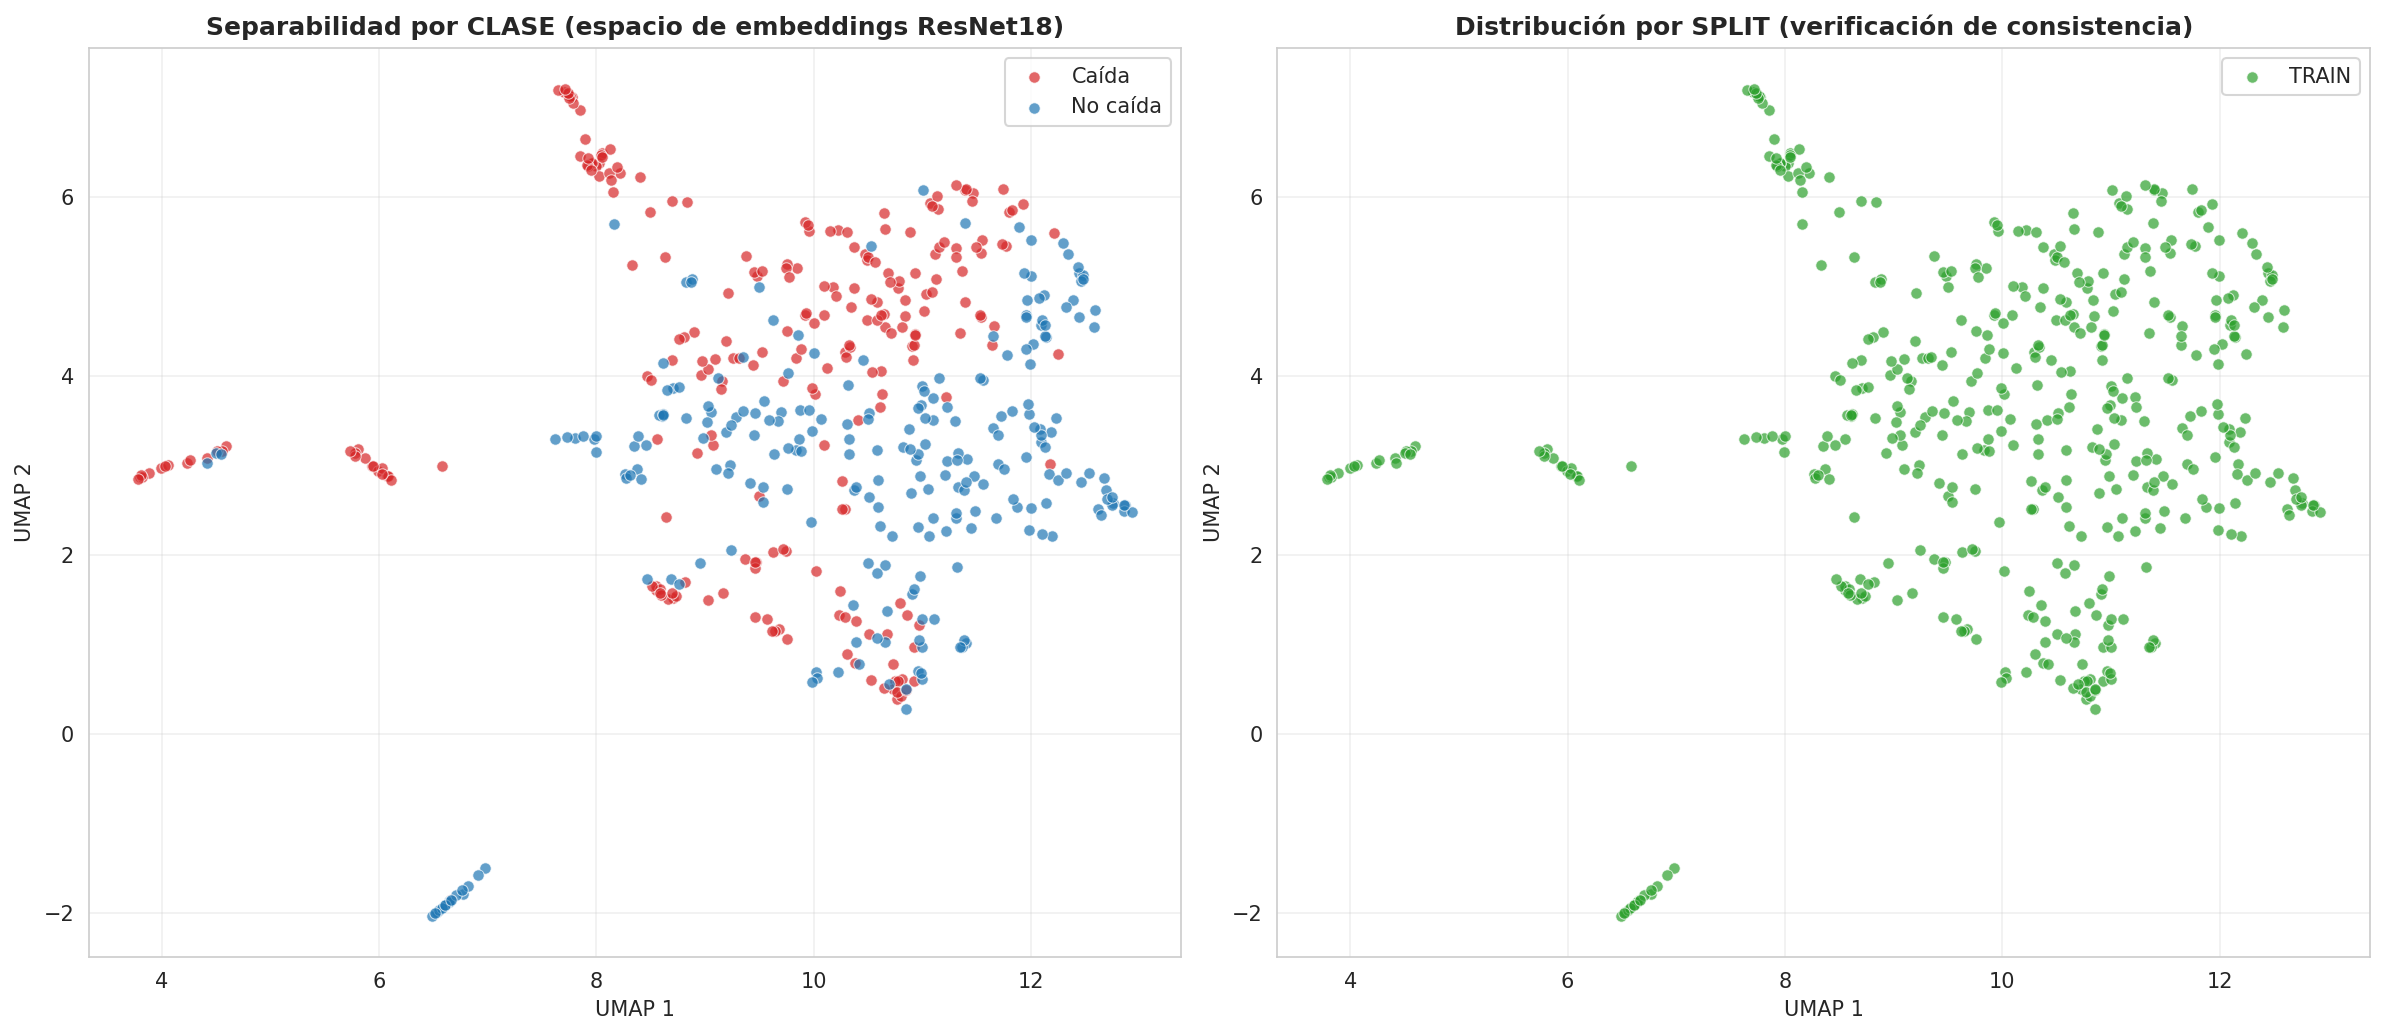


--- Evaluación cuantitativa de separabilidad ---
Accuracy de clasificación KNN en espacio de embeddings: 0.870 ± 0.017

📊 Diagnóstico de separabilidad: EXCELENTE
   → muy alta confianza en la aprendibilidad del problema


In [12]:
print("\n" + "="*70)
print("ANÁLISIS DE SEPARABILIDAD - ¿LAS CLASES SON DISTINGUIBLES?")
print("="*70)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

# Cargar modelo pre-entrenado (sin última capa)
print("Cargando ResNet18 pre-entrenada...")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Eliminar FC layer
model.to(DEVICE)
model.eval()

# Transformaciones estándar para ImageNet
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_embeddings(df_subset, max_samples=400):
    """Extrae embeddings para visualización."""
    # Muestreo balanceado
    n_fall = len(df_subset[df_subset['label'] == 'fall'])
    n_notfall = len(df_subset[df_subset['label'] == 'not_fall'])

    target_per_class = min(max_samples // 2, n_fall, n_notfall)

    fall_samples = df_subset[df_subset['label'] == 'fall'].sample(target_per_class, random_state=42)
    notfall_samples = df_subset[df_subset['label'] == 'not_fall'].sample(target_per_class, random_state=42)

    sample_df = pd.concat([fall_samples, notfall_samples])

    embeddings = []
    labels = []
    splits = []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Extrayendo embeddings"):
        try:
            img = Image.open(row['path']).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                emb = model(img_tensor).flatten().cpu().numpy()
            embeddings.append(emb)
            labels.append(row['label'])
            splits.append(row['split'])
        except Exception as e:
            print(f"Error: {e}")
            continue

    return np.array(embeddings), np.array(labels), np.array(splits)

# Extraer embeddings (usando train principalmente)
print("\nExtrayendo embeddings del dataset (train)...")
embeddings, labels, splits = extract_embeddings(
    df_fused[df_fused['split'] == 'train'],
    max_samples=500
)

# Reducción con UMAP (más reproducible que t-SNE)
print("Aplicando UMAP para reducción dimensional...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Por clase
colors_class = {'fall': '#d62728', 'not_fall': '#1f77b4'}
for label in np.unique(labels):
    mask = labels == label
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    c=colors_class[label], label='Caída' if label == 'fall' else 'No caída',
                    alpha=0.7, s=30, edgecolors='white', linewidth=0.5)
axes[0].set_title('Separabilidad por CLASE (espacio de embeddings ResNet18)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Por split (solo para verificar consistencia)
colors_split = {'train': '#2ca02c', 'valid': '#ff7f0e', 'test': '#9467bd'}
for split_name in np.unique(splits):
    mask = splits == split_name
    axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    c=colors_split.get(split_name, '#7f7f7f'), label=split_name.upper(),
                    alpha=0.7, s=30, edgecolors='white', linewidth=0.5)
axes[1].set_title('Distribución por SPLIT (verificación de consistencia)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación cuantitativa de separabilidad
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print("\n--- Evaluación cuantitativa de separabilidad ---")
knn = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn, embeddings, labels, cv=5, scoring='accuracy')
print(f"Accuracy de clasificación KNN en espacio de embeddings: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

if cv_scores.mean() > 0.85:
    separability = "EXCELENTE"
    confidence = "muy alta confianza en la aprendibilidad del problema"
elif cv_scores.mean() > 0.75:
    separability = "BUENA"
    confidence = "buena separabilidad, el modelo debería converger adecuadamente"
elif cv_scores.mean() > 0.65:
    separability = "MODERADA"
    confidence = "separabilidad moderada, se recomienda aumentar datos o usar arquitectura más potente"
else:
    separability = "BAJA"
    confidence = "baja separabilidad, revisar calidad de etiquetas o considerar características adicionales"

print(f"\n📊 Diagnóstico de separabilidad: {separability}")
print(f"   → {confidence}")


# Conclusiones Generales

## Aptitud del Dataset

El análisis realizado permite concluir que el conjunto de datos es adecuado para abordar un problema de clasificación binaria orientado a la detección de caídas.

## Balance de Clases

La distribución observada entre las categorías *Fall* y *Not Fall* resulta satisfactoria y no presenta desbalances significativos que comprometan el entrenamiento del modelo.

## Riesgo de Data Leakage

Si bien se encontrò evidencia empírica de fuga de información entre los conjuntos de entrenamiento, validación y prueba, no aporta desconfianza sobre la validez de las métricas que se obtengan en etapas posteriores.

## Separabilidad de las Clases

Los análisis exploratorios sugieren que las clases presentan patrones diferenciables, lo que constituye una señal positiva para el desarrollo de modelos predictivos.

---

El entrenamiento de una arquitectura multimodal y la posterior exposición del modelo mediante servicios de inferencia online **(SI LLEGAMOS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!)** y batch.

En conjunto, los hallazgos indican que el dataset proporciona una base sólida para el desarrollo de un sistema de clasificación de eventos de caída orientado a escenarios reales.

---